# UC3 Layer 3 — One-Class SVM (Zero-Day Attack Detection)

**Goal:** Train a One-Class SVM on benign-only CSIC 2010 HTTP data to catch attacks
that escape Layer 2 (Isolation Forest). OC-SVM learns a tight decision boundary
around the support vectors of normal traffic, making it sensitive to requests that
are *locally* unusual — complementary to IF's *global* anomaly detection.

**Dataset:** CSIC 2010 

**Split:**
- **Train (80%):** drawn from `normalTrafficTraining.csv` (benign only) — used to fit OC-SVM
- **Val (20%):** held-out benign from `normalTrafficTraining.csv` — used for threshold tuning
- **Test:** `normalTrafficTest.csv` (label=0) + `anomalousTrafficTest.csv` (label=1)

**Feature vector (4-dim, shared with Layer 2):** `request_length`, `special_char_count`,
`url_entropy`, `param_count`

**Key design decisions:**
- **Independent scaler:** OC-SVM trains on a (possibly subsampled) subset, so its
  `StandardScaler` sees different statistics than Layer 2's scaler. Sharing would
  silently break feature scaling.
- **Subsampling:** OC-SVM training is O(n²–n³). Capped at `MAX_FIT_SAMPLES`
  for tractability.
- **Threshold tuning:** `decision_function` threshold set on the benign validation
  set to achieve a target FPR, rather than relying on the default `predict()`.

**Pipeline:**
1. Load parsed CSVs
2. Feature extraction (same function as Layer 2 — training-inference parity)
3. Train/val split on benign training data
4. Scale features (independent `StandardScaler`)
5. Train One-Class SVM
6. Threshold tuning on benign validation set
7. Evaluation: confusion matrix, classification report, PR-AUC, ROC-AUC
8. Score distribution analysis
9. False negative / false positive analysis
10. Persist scaler + model + threshold via `joblib`

In [1]:
import os
import numpy as np
import pandas as pd
import math
import joblib
from urllib.parse import unquote, urlparse, parse_qs

from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score,
    roc_auc_score, roc_curve,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Configuration ──────────────────────────────────────────────────────
CSV_DIR   = "./data"  
MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)

STRUCTURAL_FEATURE_COLS = [
    "request_length", "special_char_count", "special_char_ratio",
    "url_entropy", "body_entropy", "param_count",
    "max_param_value_length", "url_path_depth", "has_body",
]
VOCAB_FEATURE_COLS = [
    "unknown_param_name_count",
    "unknown_param_name_ratio",
    "max_param_name_min_edit_dist",
]
FEATURE_COLS = STRUCTURAL_FEATURE_COLS + VOCAB_FEATURE_COLS

RANDOM_STATE = 42

# ── OC-SVM hyperparameters ────────────────────────────────────────────
VAL_SIZE        = 0.2        # fraction of training data held out for threshold tuning
KERNEL          = "rbf"
NU              = 0.05       # upper bound on fraction of training errors (was 0.01)
GAMMA           = "scale"    # 1 / (n_features * X.var())
MAX_FIT_SAMPLES = 20_000     # OC-SVM is O(n²~n³); set None to use all
TARGET_FPR      = 0.01       # target false positive rate for threshold tuning

print("Ready.")

Ready.


## 1. Load Parsed CSVs

In [2]:
df_train = pd.read_csv(os.path.join(CSV_DIR, "normalTrafficTraining.csv"))
df_test_benign = pd.read_csv(os.path.join(CSV_DIR, "normalTrafficTest.csv"))
df_test_attack = pd.read_csv(os.path.join(CSV_DIR, "anomalousTrafficTest.csv"))

df_test = pd.concat([df_test_benign, df_test_attack], ignore_index=True)

print(f"Train (benign, full): {len(df_train):>6,}")
print(f"Test  (benign):       {len(df_test_benign):>6,}")
print(f"Test  (attack):       {len(df_test_attack):>6,}")
print(f"Test  (combined):     {len(df_test):>6,}")
print(f"\nTest label distribution:\n{df_test['label'].value_counts().to_dict()}")

Train (benign, full): 36,000
Test  (benign):       36,000
Test  (attack):       25,065
Test  (combined):     61,065

Test label distribution:
{0: 36000, 1: 25065}


## 2. Feature Extraction

Same function as Layer 2 — guarantees training-inference feature parity across layers.
URL-decode **before** computing features.

In [3]:
SPECIAL_CHARS = set("'\";<>(){}[]|$`!@#%^*~")

def _shannon_entropy(s: str) -> float:
    if not s:
        return 0.0
    length = len(s)
    freq = {}
    for ch in s:
        freq[ch] = freq.get(ch, 0) + 1
    return -sum((c / length) * math.log2(c / length) for c in freq.values())


def _count_special_chars(s: str) -> int:
    return sum(1 for ch in s if ch in SPECIAL_CHARS)


def _count_params(url: str, body: str, content_type: str) -> int:
    n = 0
    # URL query params
    try:
        parsed = urlparse(url)
        n += len(parse_qs(parsed.query, keep_blank_values=True))
    except Exception:
        pass
    # POST body params (only for form-urlencoded)
    if isinstance(body, str) and isinstance(content_type, str):
        if "application/x-www-form-urlencoded" in content_type.lower():
            try:
                n += len(parse_qs(body, keep_blank_values=True))
            except Exception:
                pass
    return n

def _max_param_value_length(url: str, body: str, content_type: str) -> int:
    vals = []

    try:
        parsed = urlparse(url)
        for v_list in parse_qs(parsed.query, keep_blank_values=True).values():
            vals.extend(v_list)
    except Exception:
        pass

    if isinstance(body, str) and isinstance(content_type, str):
        if "application/x-www-form-urlencoded" in content_type.lower():
            try:
                for v_list in parse_qs(body, keep_blank_values=True).values():
                    vals.extend(v_list)
            except Exception:
                pass

    return max((len(v) for v in vals), default=0)


def _url_path_depth(url: str) -> int:
    try:
        path = urlparse(url).path
        segments = [s for s in path.split("/") if s]
        return len(segments)
    except Exception:
        return 0


def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    # URL-decode first
    decoded_url  = df["url"].fillna("").apply(lambda u: unquote(u))
    decoded_body = df["body"].fillna("")

    # Reconstruct full request string for request_length
    full_request = (
        df["method"].fillna("") + " "
        + decoded_url + " "
        + df["protocol"].fillna("") + "\n"
        + df["headers_raw"].fillna("") + "\n\n"
        + decoded_body
    )

    combined = decoded_url + decoded_body
    spec_count = combined.apply(_count_special_chars)
    combined_len = combined.str.len().replace(0, 1)  # avoid div-by-zero

    features = pd.DataFrame({
        "request_length":       full_request.str.len(),
        "special_char_count":   spec_count,
        "special_char_ratio":   spec_count / combined_len,
        "url_entropy":          decoded_url.apply(_shannon_entropy),
        "body_entropy":         decoded_body.apply(_shannon_entropy),
        "param_count":          [
            _count_params(u, b, ct)
            for u, b, ct in zip(
                decoded_url, decoded_body, df["content_type"].fillna(""),
            )
        ],
        "max_param_value_length": [
            _max_param_value_length(u, b, ct)
            for u, b, ct in zip(
                decoded_url, decoded_body, df["content_type"].fillna(""),
            )
        ],
        "url_path_depth":       decoded_url.apply(_url_path_depth),
        "has_body":             (decoded_body.str.len() > 0).astype(int),
    })
    return features


print("Feature extraction function defined.")

class ParamVocab:
    """Parameter-name vocabulary learned from benign traffic."""

    def __init__(self):
        self.known_names: set = set()

    @staticmethod
    def _parse_params(url: str, body: str, content_type: str) -> dict:
        params = {}
        try:
            parsed = urlparse(unquote(url))
            params.update(parse_qs(parsed.query, keep_blank_values=True))
        except Exception:
            pass
        if isinstance(body, str) and isinstance(content_type, str):
            if "application/x-www-form-urlencoded" in content_type.lower():
                try:
                    params.update(parse_qs(body, keep_blank_values=True))
                except Exception:
                    pass
        return params

    @staticmethod
    def _levenshtein(s1: str, s2: str) -> int:
        if len(s1) < len(s2):
            return ParamVocab._levenshtein(s2, s1)
        if not s2:
            return len(s1)
        prev = list(range(len(s2) + 1))
        for i, c1 in enumerate(s1):
            curr = [i + 1]
            for j, c2 in enumerate(s2):
                curr.append(min(
                    curr[j] + 1,
                    prev[j + 1] + 1,
                    prev[j] + (0 if c1 == c2 else 1),
                ))
            prev = curr
        return prev[-1]

    def fit(self, df: pd.DataFrame) -> "ParamVocab":
        self.known_names = set()
        for url, body, ct in zip(
            df["url"].fillna(""),
            df["body"].fillna(""),
            df["content_type"].fillna(""),
        ):
            self.known_names.update(
                self._parse_params(url, body, ct).keys()
            )
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        records = []
        for url, body, ct in zip(
            df["url"].fillna(""),
            df["body"].fillna(""),
            df["content_type"].fillna(""),
        ):
            names = list(self._parse_params(url, body, ct).keys())
            total = len(names)

            if total == 0:
                records.append((0, 0.0, 0))
                continue

            unknown_count = sum(1 for n in names if n not in self.known_names)

            # Edit distance only for unknown names (known → 0, skip)
            max_min_ed = 0
            for name in names:
                if name in self.known_names:
                    continue
                if not self.known_names:
                    min_ed = len(name)
                else:
                    min_ed = min(
                        self._levenshtein(name, kn)
                        for kn in self.known_names
                    )
                max_min_ed = max(max_min_ed, min_ed)

            records.append((
                unknown_count,
                unknown_count / total,
                max_min_ed,
            ))

        return pd.DataFrame(
            records,
            columns=VOCAB_FEATURE_COLS,
            index=df.index,
        )

print("ParamVocab defined.")

Feature extraction function defined.
ParamVocab defined.


## 3. Compute Feature Matrices

In [4]:
vocab = ParamVocab().fit(df_train)
print(f"Param vocab: {len(vocab.known_names)} unique names")
print(f"  Names: {sorted(vocab.known_names)}")

X_train = pd.concat([
    extract_features(df_train),
    vocab.transform(df_train),
], axis=1)

X_test = pd.concat([
    extract_features(df_test),
    vocab.transform(df_test),
], axis=1)

y_test = df_test["label"].values

print(f"\nTrain feature matrix: {X_train.shape}")  # expect (36000, 12)
print(f"Test  feature matrix: {X_test.shape}")     # expect (61065, 12)

# Verify vocab features are zero for benign training data
print(f"\nVocab features on train (should be all zeros):")
print(X_train[VOCAB_FEATURE_COLS].describe().round(4))

print(f"\nVocab features on test:")
print(X_test[VOCAB_FEATURE_COLS].describe().round(4))

Param vocab: 20 unique names
  Names: ['B1', 'B2', 'apellidos', 'cantidad', 'ciudad', 'cp', 'direccion', 'dni', 'email', 'errorMsg', 'id', 'login', 'modo', 'nombre', 'ntc', 'password', 'precio', 'provincia', 'pwd', 'remember']



Train feature matrix: (36000, 12)
Test  feature matrix: (61065, 12)

Vocab features on train (should be all zeros):
       unknown_param_name_count  unknown_param_name_ratio  \
count                   36000.0                   36000.0   
mean                        0.0                       0.0   
std                         0.0                       0.0   
min                         0.0                       0.0   
25%                         0.0                       0.0   
50%                         0.0                       0.0   
75%                         0.0                       0.0   
max                         0.0                       0.0   

       max_param_name_min_edit_dist  
count                       36000.0  
mean                            0.0  
std                             0.0  
min                             0.0  
25%                             0.0  
50%                             0.0  
75%                             0.0  
max                          

## 4. Train / Validation Split

Hold out 20% of benign training data for threshold tuning.
The remaining 80% is used to fit the OC-SVM (possibly subsampled further).

In [5]:
X_fit, X_val = train_test_split(
    X_train, test_size=VAL_SIZE, random_state=RANDOM_STATE
)

# Subsample fit set for OC-SVM tractability
if MAX_FIT_SAMPLES is not None and len(X_fit) > MAX_FIT_SAMPLES:
    X_fit = X_fit.sample(n=MAX_FIT_SAMPLES, random_state=RANDOM_STATE)
    print(f"Subsampled fit set to {MAX_FIT_SAMPLES:,} for OC-SVM tractability.")

print(f"Fit set:  {len(X_fit):,}")
print(f"Val set:  {len(X_val):,} (benign-only, for threshold tuning)")

Subsampled fit set to 20,000 for OC-SVM tractability.
Fit set:  20,000
Val set:  7,200 (benign-only, for threshold tuning)


## 5. Scale Features & Train One-Class SVM

- **Independent scaler** — fit on the OC-SVM fit set only (NOT shared with Layer 2).
- `kernel="rbf"`, `nu=0.01`, `gamma="scale"` — standard starting point for OC-SVM.
- `nu` is the upper bound on the fraction of training samples classified as outliers.

In [6]:
svm_scaler = StandardScaler()
X_fit_scaled = svm_scaler.fit_transform(X_fit[FEATURE_COLS])

print(f"Scaled fit mean: {X_fit_scaled.mean(axis=0).round(4)}")
print(f"Scaled fit std:  {X_fit_scaled.std(axis=0).round(4)}")

print(f"\nTraining OC-SVM (kernel={KERNEL}, nu={NU}, gamma={GAMMA})...")
print(f"  Fit samples: {len(X_fit_scaled):,}  (this may take a minute)")

ocsvm = OneClassSVM(
    kernel=KERNEL,
    nu=NU,
    gamma=GAMMA,
)
ocsvm.fit(X_fit_scaled)

n_sv = ocsvm.support_vectors_.shape[0]
print(f"\nOC-SVM fitted.")
print(f"  Support vectors: {n_sv:,} / {len(X_fit_scaled):,} "
      f"({n_sv / len(X_fit_scaled) * 100:.1f}%)")

Scaled fit mean: [ 0.  0. -0. -0.  0.  0. -0. -0.  0.  0.  0.  0.]
Scaled fit std:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0.]

Training OC-SVM (kernel=rbf, nu=0.05, gamma=scale)...
  Fit samples: 20,000  (this may take a minute)



OC-SVM fitted.
  Support vectors: 1,011 / 20,000 (5.1%)


## 6. Threshold Tuning on Benign Validation Set

Set the `decision_function` threshold so that the false positive rate on
held-out benign data matches `TARGET_FPR`. This is more principled than
relying on `predict()`, which uses `nu` as a proxy for contamination.

Threshold tuning on 7,200 benign validation samples:
  Default predict() FPR: 0.1426
  Tuned threshold:       -7.8409  (target FPR=0.01)
  Tuned FPR on val:      0.0100


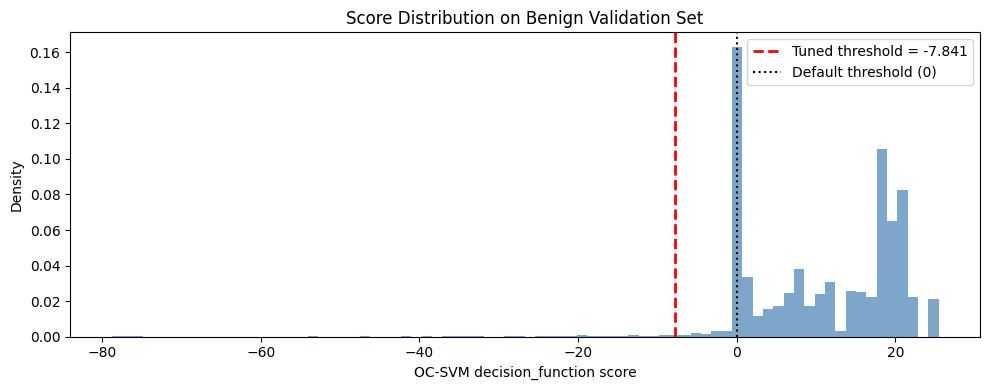

In [7]:
X_val_scaled = svm_scaler.transform(X_val[FEATURE_COLS])
val_scores   = ocsvm.decision_function(X_val_scaled)

# Threshold: percentile such that TARGET_FPR fraction of benign is below it
svm_threshold = np.percentile(val_scores, TARGET_FPR * 100)

val_preds_default = (ocsvm.predict(X_val_scaled) == -1).astype(int)
val_preds_tuned   = (val_scores < svm_threshold).astype(int)

print(f"Threshold tuning on {len(X_val):,} benign validation samples:")
print(f"  Default predict() FPR: {val_preds_default.mean():.4f}")
print(f"  Tuned threshold:       {svm_threshold:.4f}  (target FPR={TARGET_FPR})")
print(f"  Tuned FPR on val:      {val_preds_tuned.mean():.4f}")

# Distribution of val scores
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(val_scores, bins=80, alpha=0.7, color="steelblue", density=True)
ax.axvline(svm_threshold, color="red", ls="--", lw=2,
           label=f"Tuned threshold = {svm_threshold:.3f}")
ax.axvline(0, color="black", ls=":", lw=1.5, label="Default threshold (0)")
ax.set_xlabel("OC-SVM decision_function score")
ax.set_ylabel("Density")
ax.set_title("Score Distribution on Benign Validation Set")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Score Distribution on Test Set

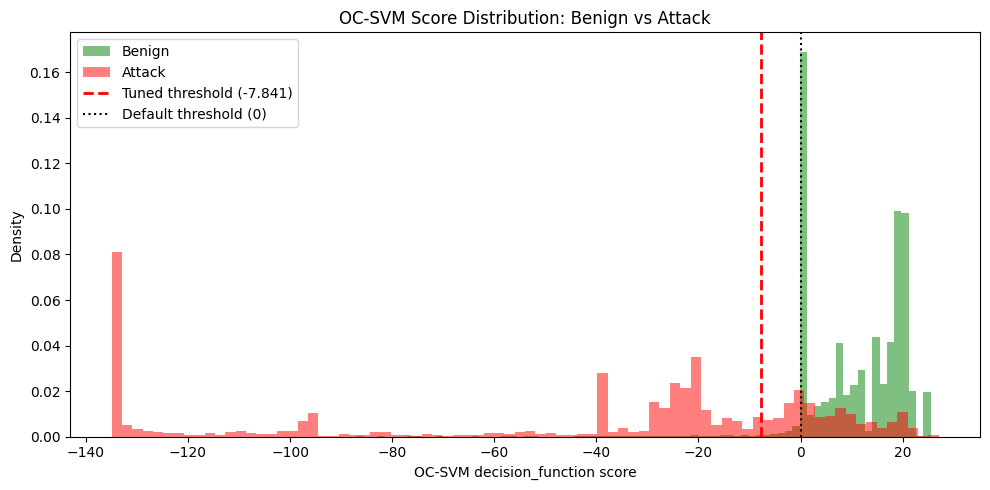

Benign scores — mean: 11.0776, std: 9.3998
Attack scores — mean: -44.8087, std: 52.8101


In [8]:
X_test_scaled = svm_scaler.transform(X_test[FEATURE_COLS])
scores_test   = ocsvm.decision_function(X_test_scaled)

benign_mask = y_test == 0
attack_mask = y_test == 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scores_test[benign_mask], bins=80, alpha=0.5, label="Benign", density=True, color="green")
ax.hist(scores_test[attack_mask], bins=80, alpha=0.5, label="Attack", density=True, color="red")
ax.axvline(svm_threshold, color="red", ls="--", lw=2, label=f"Tuned threshold ({svm_threshold:.3f})")
ax.axvline(0, color="black", ls=":", lw=1.5, label="Default threshold (0)")
ax.set_xlabel("OC-SVM decision_function score")
ax.set_ylabel("Density")
ax.set_title("OC-SVM Score Distribution: Benign vs Attack")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Benign scores — mean: {scores_test[benign_mask].mean():.4f}, "
      f"std: {scores_test[benign_mask].std():.4f}")
print(f"Attack scores — mean: {scores_test[attack_mask].mean():.4f}, "
      f"std: {scores_test[attack_mask].std():.4f}")

## 8. Evaluation at Default Threshold

=== Default threshold (predict) ===

              precision    recall  f1-score   support

      Benign       0.86      0.86      0.86     36000
      Attack       0.79      0.80      0.79     25065

    accuracy                           0.83     61065
   macro avg       0.83      0.83      0.83     61065
weighted avg       0.83      0.83      0.83     61065



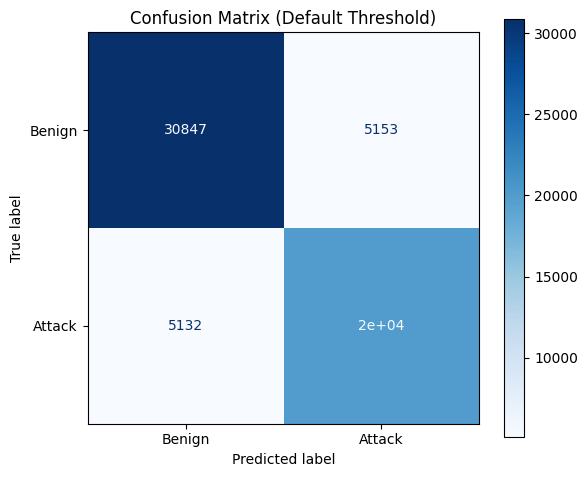

In [9]:
y_pred_default = np.where(ocsvm.predict(X_test_scaled) == -1, 1, 0)

print("=== Default threshold (predict) ===\n")
print(classification_report(y_test, y_pred_default, target_names=["Benign", "Attack"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_default,
    display_labels=["Benign", "Attack"],
    cmap="Blues", ax=ax,
)
ax.set_title("Confusion Matrix (Default Threshold)")
plt.tight_layout()
plt.show()

## 9. Evaluation at Tuned Threshold

=== Tuned threshold (score < -7.8409 → anomaly) ===

              precision    recall  f1-score   support

      Benign       0.83      0.99      0.90     36000
      Attack       0.98      0.71      0.82     25065

    accuracy                           0.87     61065
   macro avg       0.90      0.85      0.86     61065
weighted avg       0.89      0.87      0.87     61065



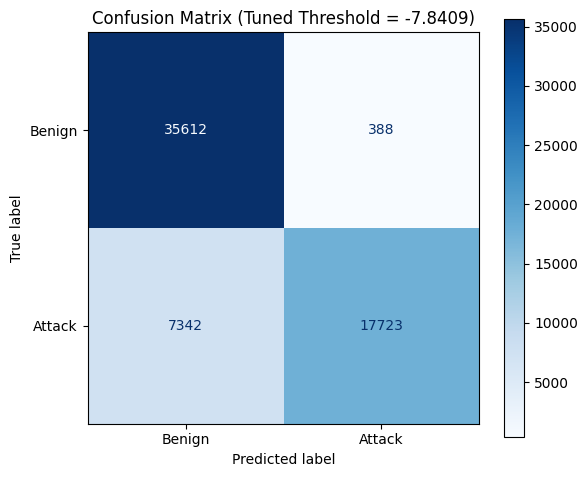

In [10]:
y_pred_tuned = np.where(scores_test < svm_threshold, 1, 0)

print(f"=== Tuned threshold (score < {svm_threshold:.4f} → anomaly) ===\n")
print(classification_report(y_test, y_pred_tuned, target_names=["Benign", "Attack"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=["Benign", "Attack"],
    cmap="Blues", ax=ax,
)
ax.set_title(f"Confusion Matrix (Tuned Threshold = {svm_threshold:.4f})")
plt.tight_layout()
plt.show()

## 10. Threshold Sweep — PR & ROC Curves

Full sweep to show the precision-recall trade-off and find the F1-maximizing
operating point (which may differ from the FPR-targeted threshold above).

PR-AUC: 0.9103
Best F1: 0.8666 at OC-SVM score threshold: -0.0288
  Precision: 0.9531
  Recall:    0.7945


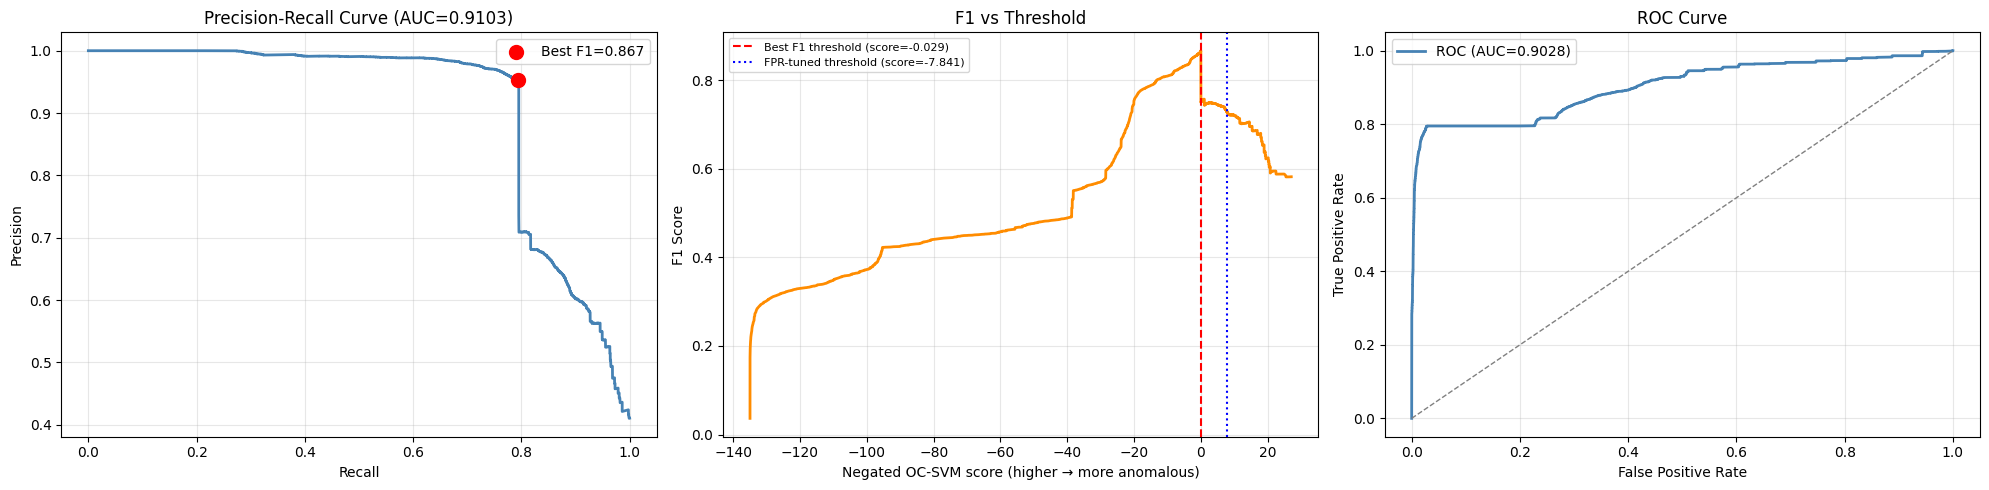


ROC-AUC: 0.9028


In [11]:
# Negate scores: higher = more anomalous for sklearn curve functions
neg_scores = -scores_test

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, neg_scores)
pr_auc = average_precision_score(y_test, neg_scores)

# F1 at each PR threshold
f1s = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10)
best_f1_idx = np.argmax(f1s)
best_f1_thresh = -thresholds_pr[best_f1_idx]  # back to OC-SVM score space

print(f"PR-AUC: {pr_auc:.4f}")
print(f"Best F1: {f1s[best_f1_idx]:.4f} at OC-SVM score threshold: {best_f1_thresh:.4f}")
print(f"  Precision: {precisions[best_f1_idx]:.4f}")
print(f"  Recall:    {recalls[best_f1_idx]:.4f}")

# ROC
roc_auc = roc_auc_score(y_test, neg_scores)
fpr_arr, tpr_arr, _ = roc_curve(y_test, neg_scores)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# PR curve
axes[0].plot(recalls, precisions, lw=2, color="steelblue")
axes[0].scatter(recalls[best_f1_idx], precisions[best_f1_idx], color="red", s=100, zorder=5,
                label=f"Best F1={f1s[best_f1_idx]:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve (AUC={pr_auc:.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs threshold
axes[1].plot(-thresholds_pr, f1s, lw=2, color="darkorange")
axes[1].axvline(-best_f1_thresh, color="red", ls="--",
                label=f"Best F1 threshold (score={best_f1_thresh:.3f})")
axes[1].axvline(-svm_threshold, color="blue", ls=":",
                label=f"FPR-tuned threshold (score={svm_threshold:.3f})")
axes[1].set_xlabel("Negated OC-SVM score (higher → more anomalous)")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 vs Threshold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# ROC curve
axes[2].plot(fpr_arr, tpr_arr, lw=2, color="steelblue", label=f"ROC (AUC={roc_auc:.4f})")
axes[2].plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nROC-AUC: {roc_auc:.4f}")

## 11. Evaluation at F1-Optimal Threshold

=== F1-optimal threshold (score < -0.0288) ===

              precision    recall  f1-score   support

      Benign       0.87      0.97      0.92     36000
      Attack       0.95      0.79      0.87     25065

    accuracy                           0.90     61065
   macro avg       0.91      0.88      0.89     61065
weighted avg       0.91      0.90      0.90     61065



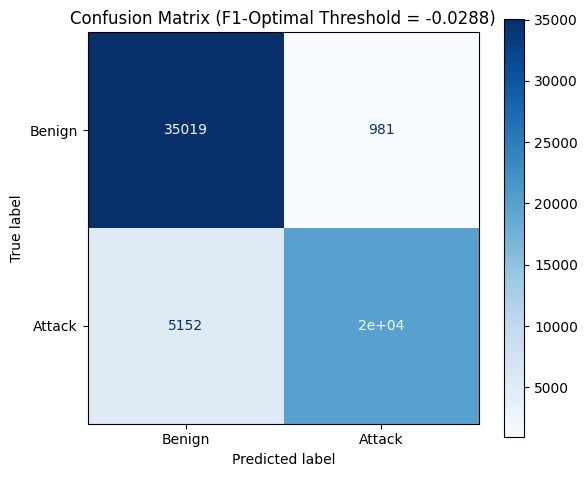

In [12]:
y_pred_f1 = np.where(scores_test < best_f1_thresh, 1, 0)

print(f"=== F1-optimal threshold (score < {best_f1_thresh:.4f}) ===\n")
print(classification_report(y_test, y_pred_f1, target_names=["Benign", "Attack"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_f1,
    display_labels=["Benign", "Attack"],
    cmap="Blues", ax=ax,
)
ax.set_title(f"Confusion Matrix (F1-Optimal Threshold = {best_f1_thresh:.4f})")
plt.tight_layout()
plt.show()

## 12. False Negative Analysis

Attacks that OC-SVM missed at the tuned threshold. These are requests that
would escape all three layers if Layer 1 and Layer 2 also missed them.

True Positives  (attacks caught): 17,723
False Negatives (attacks missed): 7,342

FN feature statistics:
       request_length  special_char_count  special_char_ratio  url_entropy  \
count         7342.00             7342.00             7342.00      7342.00   
mean           620.61                1.01                0.00         4.49   
std            118.28                1.60                0.01         0.28   
min            496.00                0.00                0.00         4.02   
25%            518.00                0.00                0.00         4.28   
50%            577.00                0.00                0.00         4.37   
75%            744.00                2.00                0.01         4.70   
max            867.00                6.00                0.03         5.22   

       body_entropy  param_count  max_param_value_length  url_path_depth  \
count       7342.00      7342.00                 7342.00         7342.00   
mean           1.40         4.89        

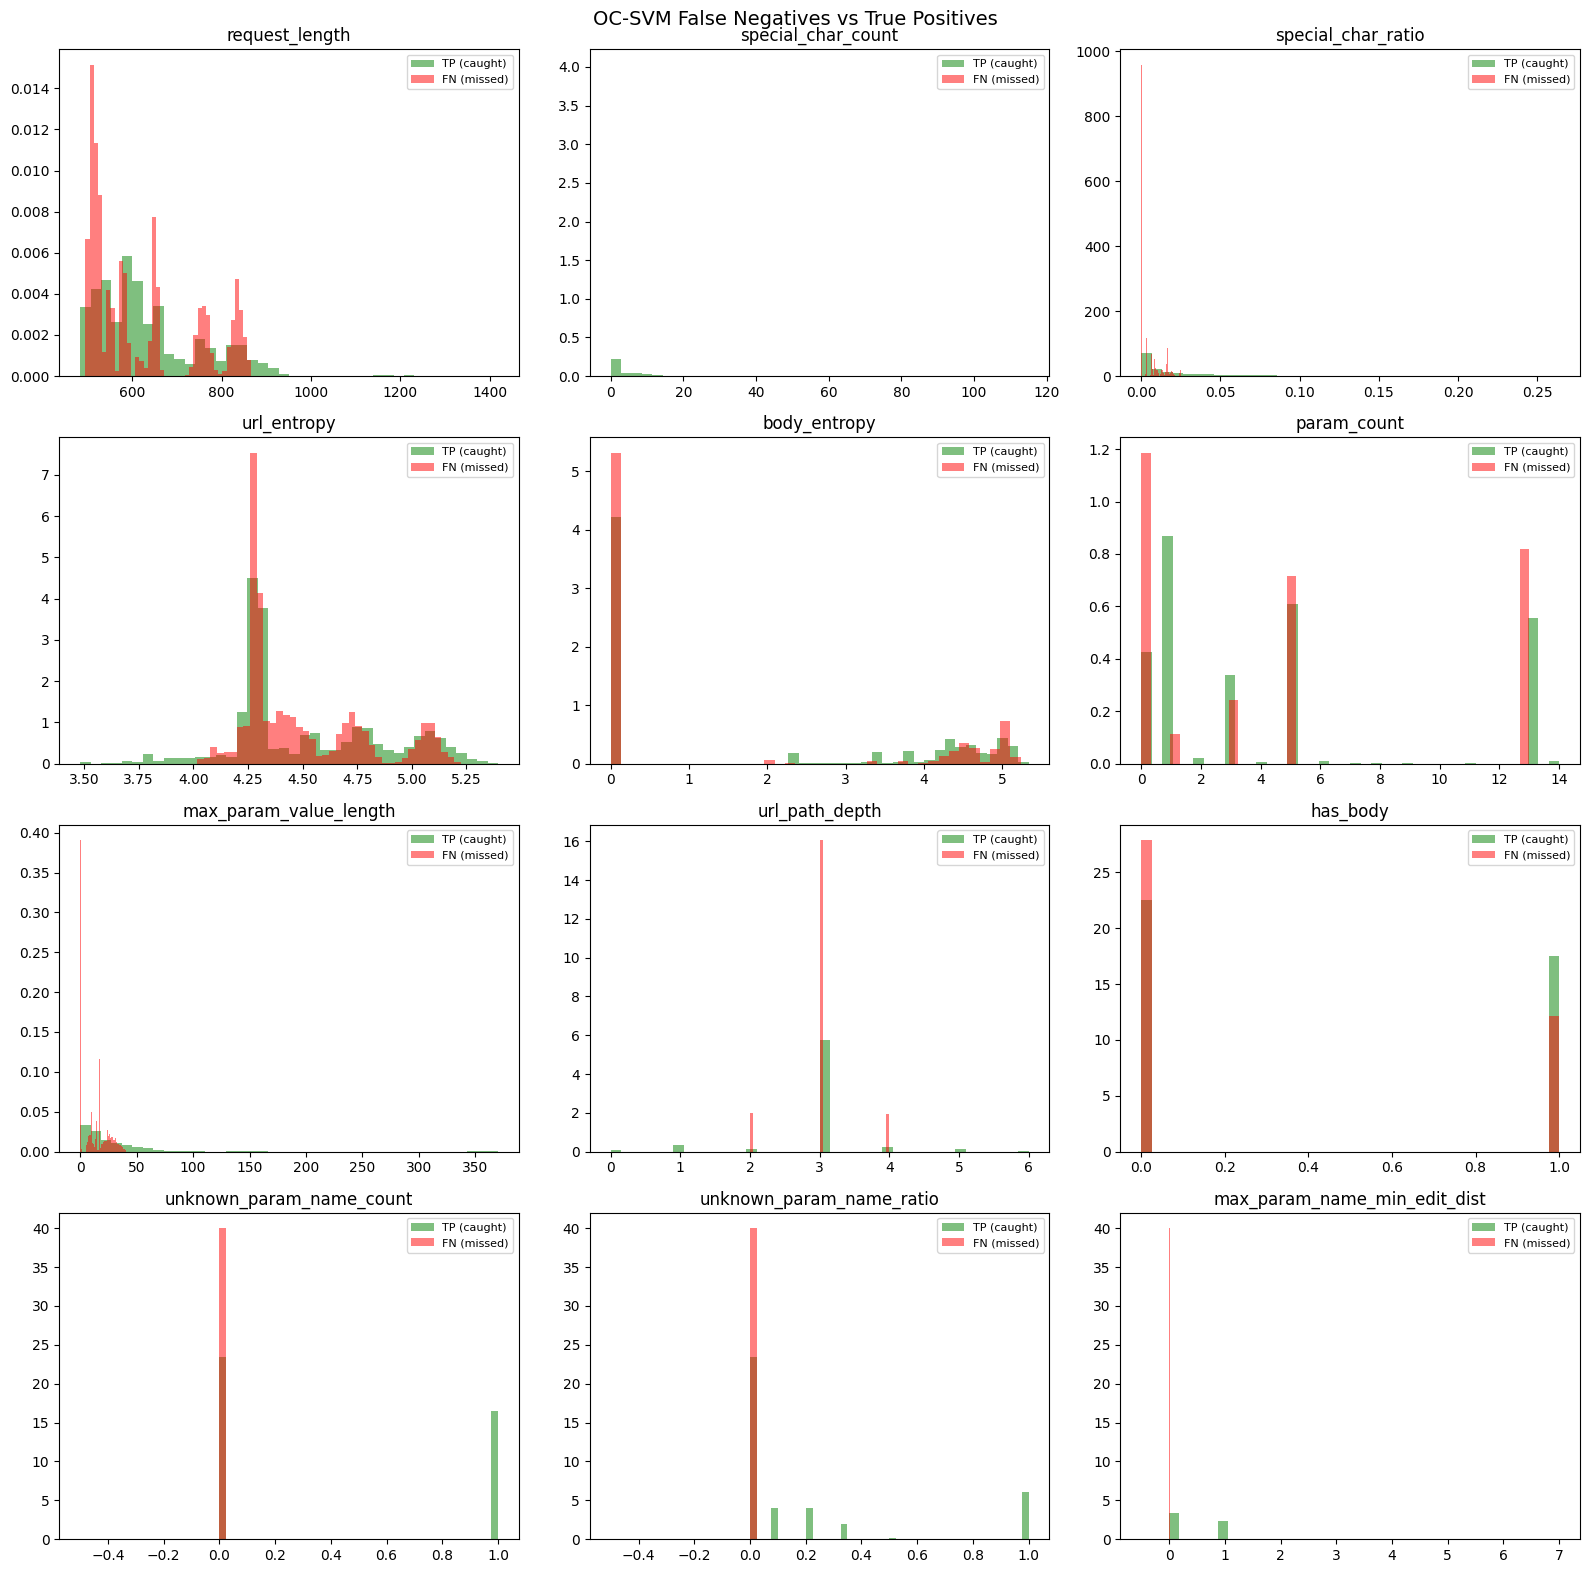

In [13]:
y_eval = y_pred_tuned  # using FPR-tuned threshold for analysis

fn_mask = (y_test == 1) & (y_eval == 0)
tp_mask = (y_test == 1) & (y_eval == 1)

fn_features = X_test.loc[fn_mask, FEATURE_COLS]
tp_features = X_test.loc[tp_mask, FEATURE_COLS]

print(f"True Positives  (attacks caught): {tp_mask.sum():,}")
print(f"False Negatives (attacks missed): {fn_mask.sum():,}")
print(f"\nFN feature statistics:\n{fn_features.describe().round(2)}")
print(f"\nTP feature statistics:\n{tp_features.describe().round(2)}")

n_feats = len(FEATURE_COLS)
ncols = 3
nrows = math.ceil(n_feats / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
for ax in axes.flat[n_feats:]:
    ax.set_visible(False)
for ax, col in zip(axes.flat, FEATURE_COLS):
    ax.hist(tp_features[col], bins=40, alpha=0.5, label="TP (caught)", density=True, color="green")
    if len(fn_features) > 0:
        ax.hist(fn_features[col], bins=40, alpha=0.5, label="FN (missed)", density=True, color="red")
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle("OC-SVM False Negatives vs True Positives", fontsize=14)
plt.tight_layout()
plt.show()

### 12.1 Sample False Negatives

In [14]:
fn_df = df_test.loc[fn_mask].copy()
fn_df = fn_df.assign(**X_test.loc[fn_mask, FEATURE_COLS].to_dict())
fn_df["svm_score"] = scores_test[fn_mask]

sample_cols = ["method", "url"] + FEATURE_COLS + ["svm_score"]
display_cols = [c for c in sample_cols if c in fn_df.columns]
print(f"Sample false negatives (attacks missed by OC-SVM):\n")
print(fn_df[display_cols].head(10).to_string(max_colwidth=80))

Sample false negatives (attacks missed by OC-SVM):

      method                                                                              url  request_length  special_char_count  special_char_ratio  url_entropy  body_entropy  param_count  max_param_value_length  url_path_depth  has_body  unknown_param_name_count  unknown_param_name_ratio  max_param_name_min_edit_dist  svm_score
36002    GET  http://localhost:8080/tienda1/publico/anadir.jsp?id=2%2F&nombre=Jam%F3n+Ib%E...             580                   0            0.000000     4.797182      0.000000            5                      17               3         0                         0                       0.0                             0   3.884284
36007    GET  http://localhost:8080/tienda1/publico/autenticar.jsp?modo=entrar&login=grims...             578                   0            0.000000     4.775249      0.000000            5                      10               3         0                         0                 

## 13. False Positive Analysis

In [15]:
fp_mask = (y_test == 0) & (y_eval == 1)
tn_mask = (y_test == 0) & (y_eval == 0)

print(f"True Negatives  (benign correctly passed): {tn_mask.sum():,}")
print(f"False Positives (benign flagged as attack): {fp_mask.sum():,}")
print(f"False Positive Rate: {fp_mask.sum() / (fp_mask.sum() + tn_mask.sum()):.4f}")

if fp_mask.sum() > 0:
    fp_features = X_test.loc[fp_mask, FEATURE_COLS]
    print(f"\nFP feature statistics:\n{fp_features.describe().round(2)}")

    fp_df = df_test.loc[fp_mask].copy()
    fp_df = fp_df.assign(**X_test.loc[fp_mask, FEATURE_COLS].to_dict())
    fp_df["svm_score"] = scores_test[fp_mask]
    sample_cols = ["method", "url"] + FEATURE_COLS + ["svm_score"]
    display_cols = [c for c in sample_cols if c in fp_df.columns]
    print(f"\nSample false positives:\n")
    print(fp_df[display_cols].head(10).to_string(max_colwidth=80))
else:
    print("No false positives at this threshold.")

True Negatives  (benign correctly passed): 35,612
False Positives (benign flagged as attack): 388
False Positive Rate: 0.0108

FP feature statistics:
       request_length  special_char_count  special_char_ratio  url_entropy  \
count          388.00              388.00              388.00       388.00   
mean           784.92                3.30                0.01         4.55   
std             96.23                2.59                0.01         0.34   
min            572.00                0.00                0.00         4.26   
25%            771.00                1.00                0.00         4.29   
50%            826.00                2.00                0.01         4.32   
75%            849.00                6.00                0.02         4.90   
max            895.00                9.00                0.03         5.27   

       body_entropy  param_count  max_param_value_length  url_path_depth  \
count        388.00       388.00                  388.00           388.

## 14. Summary

In [16]:
p_def = precision_score(y_test, y_pred_default)
r_def = recall_score(y_test, y_pred_default)
f1_def = f1_score(y_test, y_pred_default)

p_tuned = precision_score(y_test, y_pred_tuned)
r_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

p_f1 = precision_score(y_test, y_pred_f1)
r_f1 = recall_score(y_test, y_pred_f1)
f1_f1 = f1_score(y_test, y_pred_f1)

summary = pd.DataFrame({
    "Metric":     ["Precision", "Recall", "F1-Score", "PR-AUC", "ROC-AUC", "Threshold"],
    "Default":    [f"{p_def:.4f}", f"{r_def:.4f}", f"{f1_def:.4f}", "", "", "predict()"],
    "FPR-tuned":  [f"{p_tuned:.4f}", f"{r_tuned:.4f}", f"{f1_tuned:.4f}",
                   f"{pr_auc:.4f}", f"{roc_auc:.4f}", f"{svm_threshold:.4f}"],
    "F1-optimal": [f"{p_f1:.4f}", f"{r_f1:.4f}", f"{f1_f1:.4f}",
                   "", "", f"{best_f1_thresh:.4f}"],
})
print(summary.to_string(index=False))
print(f"\nRecommendation: Use the FPR-tuned threshold ({svm_threshold:.4f}) for")
print(f"production to control false alarm rate. The F1-optimal threshold")
print(f"({best_f1_thresh:.4f}) is reported for thesis completeness.")

   Metric   Default FPR-tuned F1-optimal
Precision    0.7946    0.9786     0.9530
   Recall    0.7953    0.7071     0.7945
 F1-Score    0.7949    0.8210     0.8666
   PR-AUC              0.9103           
  ROC-AUC              0.9028           
Threshold predict()   -7.8409    -0.0288



Recommendation: Use the FPR-tuned threshold (-7.8409) for
production to control false alarm rate. The F1-optimal threshold
(-0.0288) is reported for thesis completeness.


## 15. Persist Scaler + Model

Save as a single artifact dict — same pattern as Layer 2.
Independent scaler ensures no cross-layer contamination.

In [17]:
artifact = {
    "scaler": svm_scaler,
    "model": ocsvm,
    "threshold": svm_threshold,
    "threshold_f1_optimal": best_f1_thresh,
    "vocab": vocab,
    "feature_cols": FEATURE_COLS,
    "hyperparams": {
        "kernel": KERNEL,
        "nu": NU,
        "gamma": GAMMA,
        "max_fit_samples": MAX_FIT_SAMPLES,
        "val_size": VAL_SIZE,
        "target_fpr": TARGET_FPR,
    },
}

save_path = os.path.join(MODEL_DIR, "web_attack_ocsvm.pkl")
joblib.dump(artifact, save_path)

# Verify round-trip
loaded = joblib.load(save_path)
assert list(loaded["feature_cols"]) == FEATURE_COLS
print(f"Saved to {save_path}")
print(f"  FPR-tuned threshold:  {loaded['threshold']:.4f}")
print(f"  F1-optimal threshold: {loaded['threshold_f1_optimal']:.4f}")
print(f"  Features:  {loaded['feature_cols']}")
print(f"  Scaler:    {type(loaded['scaler']).__name__}")
print(f"  Model:     {type(loaded['model']).__name__}")
print(f"  Hyperparams: {loaded['hyperparams']}")

Saved to ./models\web_attack_ocsvm.pkl
  FPR-tuned threshold:  -7.8409
  F1-optimal threshold: -0.0288
  Features:  ['request_length', 'special_char_count', 'special_char_ratio', 'url_entropy', 'body_entropy', 'param_count', 'max_param_value_length', 'url_path_depth', 'has_body', 'unknown_param_name_count', 'unknown_param_name_ratio', 'max_param_name_min_edit_dist']
  Scaler:    StandardScaler
  Model:     OneClassSVM
  Hyperparams: {'kernel': 'rbf', 'nu': 0.05, 'gamma': 'scale', 'max_fit_samples': 20000, 'val_size': 0.2, 'target_fpr': 0.01}
